In [5]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.plot import show
import geopandas as gpd
from shapely.geometry import LineString, Point
import warnings
warnings.filterwarnings('ignore')

TIF_DIR  = '../input/Density_Scenarios_Paper'
NODE_CSV = '../input/AfricaNetworkNodes.csv'
EDGE_CSV = '../input/AfricaNetworkEdges_withUrban.csv'

nodes = pd.read_csv(NODE_CSV)
edges = pd.read_csv(EDGE_CSV)
print(f'Nodes: {len(nodes)}  Edges: {len(edges)}')

Nodes: 7361  Edges: 9159


## 1. 找某个城市附近的TIF文件

In [13]:
# 选一个城市来可视化
# 建议先试 Cairo（埃及，差异最大）或 Lagos
CITY_NAME = 'Lagos'   # ← 改这里
YEAR      = 2050

# 找到城市坐标
city = nodes[nodes['agglosName'].str.contains(CITY_NAME, case=False, na=False)]
print(f"找到 {len(city)} 个匹配节点:")
print(city[['agglosName','ISO3','x','y','Pop2015']].to_string())

city_row = city.iloc[0]
cx, cy = city_row['x'], city_row['y']
print(f"\n使用: {city_row['agglosName']}  lon={cx:.3f}  lat={cy:.3f}")

找到 1 个匹配节点:
    agglosName ISO3      x      y   Pop2015
317      Lagos  NGA  3.316  6.668  11847635

使用: Lagos  lon=3.316  lat=6.668


In [14]:
# 不过滤文件名，只用坐标判断覆盖
all_tifs = glob.glob(os.path.join(TIF_DIR, f'**/*{YEAR}.tif'), recursive=True)
print(f"找到 {len(all_tifs)} 个{YEAR}年TIF文件")

scenario_tifs = {}
for sc_kw, sc_label in [('highdensity','high'), ('consdensity','cons'), ('lowdensity','low')]:
    # 只按scenario关键词过滤，不管国家名
    candidates = [f for f in all_tifs if sc_kw.lower() in os.path.basename(f).lower()]
    print(f"{sc_label}: {len(candidates)} 个候选文件")
    
    covering = [f for f in candidates if tif_covers(f, cx, cy)]
    if covering:
        scenario_tifs[sc_label] = covering[0]
        print(f"  ✓ {os.path.basename(covering[0])}")
    else:
        # 调试：打印candidates的bounds看哪里不对
        print(f"  ⚠ 没找到，调试前5个候选:")
        for f in candidates[:5]:
            with rasterio.open(f) as src:
                b = src.bounds
            print(f"    {os.path.basename(f)}: lon=[{b.left:.1f},{b.right:.1f}] lat=[{b.bottom:.1f},{b.top:.1f}]")
        print(f"  城市坐标: lon={cx:.3f} lat={cy:.3f}")

找到 161 个2050年TIF文件
high: 53 个候选文件
  ✓ Nigeria_low80_highdensity_2050.tif
cons: 54 个候选文件
  ✓ Nigeria_low80_consdensity_2050.tif
low: 54 个候选文件
  ✓ Nigeria_low80_lowdensity_2050.tif


## 2. 三个scenario并排：城区范围对比

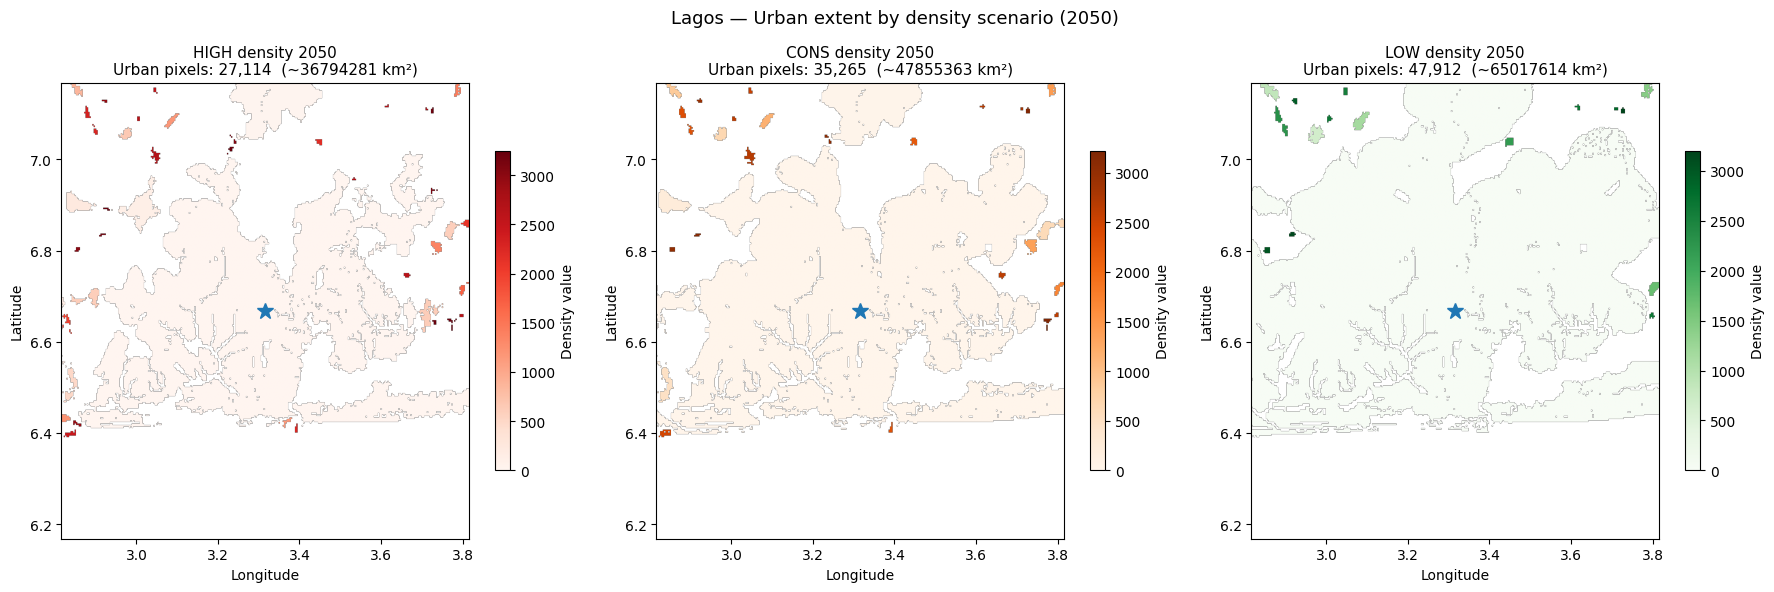

Saved: Lagos_scenarios_2050.png


In [18]:
# 裁剪范围：城市中心周围多少度
BUFFER = 0.5   # 度，约55km，可以调大/调小

bbox = {
    'left':   cx - BUFFER,
    'right':  cx + BUFFER,
    'bottom': cy - BUFFER,
    'top':    cy + BUFFER,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sc_colors = {'high': 'Reds', 'cons': 'Oranges', 'low': 'Greens'}

for ax, (sc_label, tif_path) in zip(axes, scenario_tifs.items()):
    with rasterio.open(tif_path) as src:
        # 裁剪到bbox
        window = src.window(bbox['left'], bbox['bottom'], bbox['right'], bbox['top'])
        data   = src.read(1, window=window)
        nodata = src.nodata
        transform = src.window_transform(window)
    
    data = data.astype(float)
    if nodata is not None:
        data[data == nodata] = np.nan
    
    # 统计
    urban_pixels = np.nansum(data > 0)
    total_pixels = np.sum(~np.isnan(data))
    pixel_size_km = 0.333 * 111  # 度转km
    urban_area_km2 = urban_pixels * (pixel_size_km ** 2 / 111**2 * 111**2)  
    # 简化：1pixel ≈ (0.333*111km)^2 但我们用实际度数
    urban_area_km2 = urban_pixels * (0.333 ** 2) * (111 ** 2) / (111 ** 2) * 111**2
    urban_area_km2 = urban_pixels * 0.333 * 0.333 * np.cos(np.radians(cy)) * 111 * 111

    # 显示：只显示城区（>0）
    display = np.where(data > 0, data, np.nan)
    
    extent = [bbox['left'], bbox['right'], bbox['bottom'], bbox['top']]
    
    # 背景（非城区）灰色
    ax.imshow(np.where(np.isnan(data), np.nan, 0),
              extent=extent, aspect='auto', cmap='Greys', vmin=0, vmax=1, alpha=0.15)
    # 城区
    im = ax.imshow(display, extent=extent, aspect='auto',
                   cmap=sc_colors[sc_label], vmin=0, origin='upper')
    
    # 城市中心点
    ax.plot(cx, cy, '*', markersize=12, label=CITY_NAME)
    
    ax.set_title(f'{sc_label.upper()} density {YEAR}\n'
                 f'Urban pixels: {urban_pixels:,}  (~{urban_area_km2:.0f} km²)',
                 fontsize=11)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.colorbar(im, ax=ax, shrink=0.7, label='Density value')

fig.suptitle(f'{CITY_NAME} — Urban extent by density scenario ({YEAR})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CITY_NAME}_scenarios_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CITY_NAME}_scenarios_{YEAR}.png')

## 3. 叠加路网边：看哪些边穿越城区

In [16]:
# 找bbox内的节点和边
nodes_in = nodes[
    (nodes['x'] >= bbox['left'])  & (nodes['x'] <= bbox['right']) &
    (nodes['y'] >= bbox['bottom']) & (nodes['y'] <= bbox['top'])
].copy()

node_set = set(nodes_in['name'])
edges_in = edges[
    edges['from'].isin(node_set) | edges['to'].isin(node_set)
].copy()

print(f'Nodes in bbox: {len(nodes_in)}')
print(f'Edges in bbox: {len(edges_in)}')

# 坐标查找表
xy = nodes.set_index('name')[['x','y']]

Nodes in bbox: 31
Edges in bbox: 48


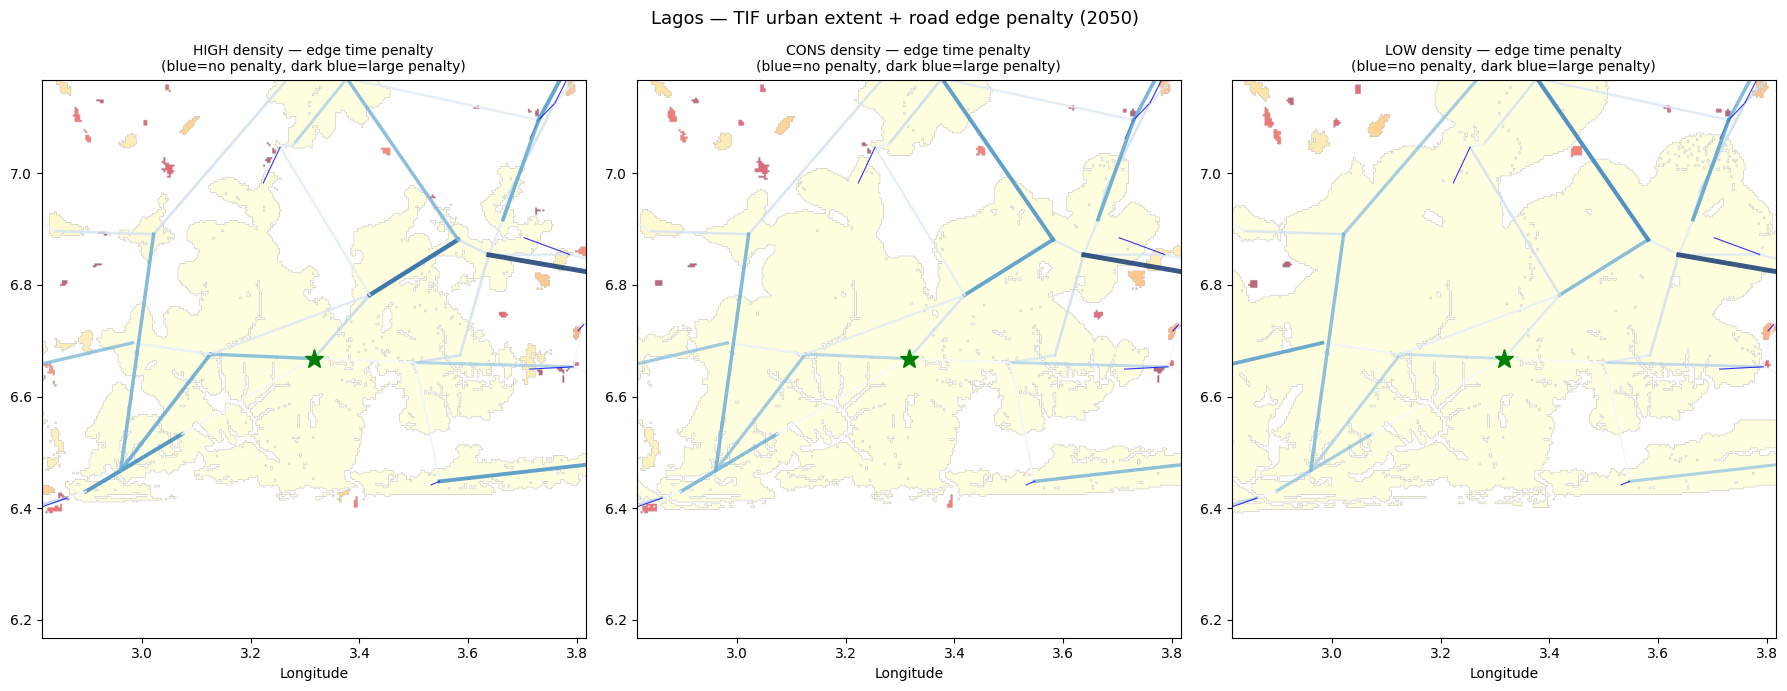

Saved: Lagos_edges_overlay_2050.png


In [17]:
# 并排显示三个scenario + 路网叠加
# 路段按 urban_frac 着色（城区比例）

# 计算每条边的 urban_frac（从 timeU_high/cons/lowd2050 反推）
# urban_frac = (time_new - time_orig) / (l/v_urban*60 - time_orig)
# 但这个反推比较复杂，直接用时间增量的相对值来着色
V_URBAN = 30.0

for sc_label, time_col in [('high','timeU_high2050'),('cons','timeU_cons2050'),('low','timeU_lowd2050')]:
    if time_col not in edges_in.columns:
        print(f'⚠ {time_col} not in edges')
        continue
    # 时间增量（分钟）
    edges_in[f'delta_{sc_label}'] = edges_in[time_col] - edges_in['time']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (sc_label, tif_path) in zip(axes, scenario_tifs.items()):
    # TIF背景
    with rasterio.open(tif_path) as src:
        window = src.window(bbox['left'], bbox['bottom'], bbox['right'], bbox['top'])
        data   = src.read(1, window=window).astype(float)
        nodata = src.nodata
    if nodata is not None:
        data[data == nodata] = np.nan
    
    extent = [bbox['left'], bbox['right'], bbox['bottom'], bbox['top']]
    display = np.where(data > 0, data, np.nan)
    
    ax.imshow(display, extent=extent, aspect='auto',
              cmap='YlOrRd', alpha=0.6, origin='upper')
    
    # 路网边：按时间增量着色
    delta_col = f'delta_{sc_label}'
    if delta_col in edges_in.columns:
        max_delta = edges_in[delta_col].abs().max()
        norm = mcolors.Normalize(vmin=0, vmax=max(max_delta, 1))
        cmap_edge = plt.cm.Blues
        
        for _, row in edges_in.iterrows():
            try:
                x0, y0 = xy.loc[row['from']]
                x1, y1 = xy.loc[row['to']]
            except KeyError:
                continue
            delta = row[delta_col]
            color = 'blue' if delta <= 0.1 else cmap_edge(norm(delta))
            lw    = 0.8 if delta <= 0.1 else 1.5 + norm(delta) * 2
            ax.plot([x0, x1], [y0, y1], color=color, linewidth=lw, alpha=0.8)
    
    ax.plot(cx, cy, 'g*', markersize=14)
    ax.set_xlim(bbox['left'], bbox['right'])
    ax.set_ylim(bbox['bottom'], bbox['top'])
    ax.set_title(f'{sc_label.upper()} density — edge time penalty\n'
                 f'(blue=no penalty, dark blue=large penalty)', fontsize=10)
    ax.set_xlabel('Longitude')

fig.suptitle(f'{CITY_NAME} — TIF urban extent + road edge penalty ({YEAR})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CITY_NAME}_edges_overlay_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CITY_NAME}_edges_overlay_{YEAR}.png')

## 4. 单个scenario的详细视图 + 像素值分布

=== Lagos — low density 2050 ===
Pixel size: 0.0033° × 0.0033°  ≈ 0.37 × 0.37 km
Total pixels in view: 90,000
Urban pixels (>0):    47,912
Urban coverage:       53.2%

Pixel value stats (urban only):
  min=1  median=1  mean=19.0  max=3198


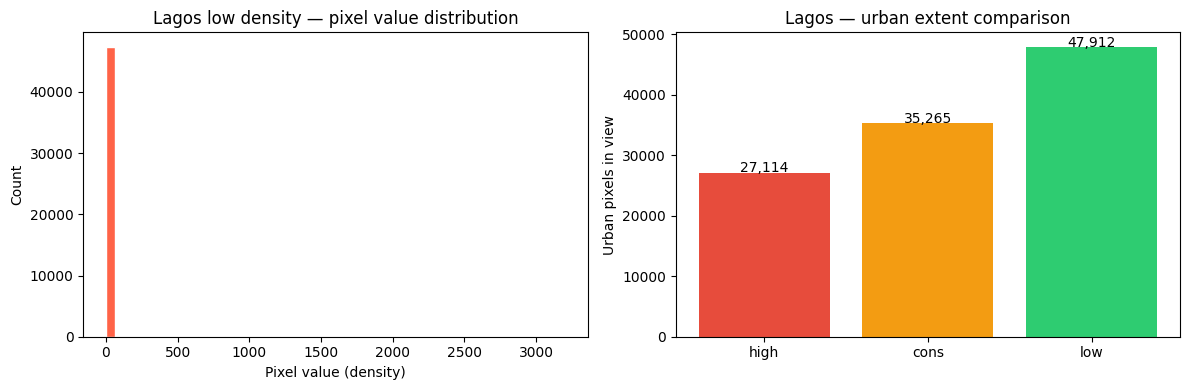


Urban pixel counts by scenario:
  high: 27,114
  cons: 35,265
  low: 47,912


In [19]:
# 详细看一个scenario的像素值
SC_FOCUS = 'low'   # ← high / cons / low

with rasterio.open(scenario_tifs[SC_FOCUS]) as src:
    window = src.window(bbox['left'], bbox['bottom'], bbox['right'], bbox['top'])
    data   = src.read(1, window=window).astype(float)
    nodata = src.nodata
    res    = src.res

if nodata is not None:
    data[data == nodata] = np.nan

urban = data[data > 0]
print(f"=== {CITY_NAME} — {SC_FOCUS} density {YEAR} ===")
print(f"Pixel size: {res[0]:.4f}° × {res[1]:.4f}°  ≈ {res[0]*111:.2f} × {res[1]*111:.2f} km")
print(f"Total pixels in view: {np.sum(~np.isnan(data)):,}")
print(f"Urban pixels (>0):    {len(urban):,}")
print(f"Urban coverage:       {len(urban)/np.sum(~np.isnan(data))*100:.1f}%")
print(f"\nPixel value stats (urban only):")
print(f"  min={urban.min():.0f}  median={np.median(urban):.0f}  "
      f"mean={urban.mean():.1f}  max={urban.max():.0f}")

# 分布直方图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(urban, bins=50, color='tomato', edgecolor='white')
ax1.set_xlabel('Pixel value (density)')
ax1.set_ylabel('Count')
ax1.set_title(f'{CITY_NAME} {SC_FOCUS} density — pixel value distribution')

# 三个scenario的urban像素数对比
sc_counts = {}
for sc, path in scenario_tifs.items():
    with rasterio.open(path) as src:
        window = src.window(bbox['left'], bbox['bottom'], bbox['right'], bbox['top'])
        d = src.read(1, window=window).astype(float)
        nd = src.nodata
    if nd is not None: d[d==nd] = np.nan
    sc_counts[sc] = int(np.nansum(d > 0))

ax2.bar(sc_counts.keys(), sc_counts.values(),
        color=['#e74c3c','#f39c12','#2ecc71'])
ax2.set_ylabel('Urban pixels in view')
ax2.set_title(f'{CITY_NAME} — urban extent comparison')
for sc, cnt in sc_counts.items():
    ax2.text(sc, cnt + 50, f'{cnt:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nUrban pixel counts by scenario:")
for sc, cnt in sc_counts.items():
    print(f"  {sc}: {cnt:,}")

## 5. 时间序列：城区扩张过程（2020→2050）

Found time series: [2020, 2025, 2030, 2035, 2040, 2045, 2050]


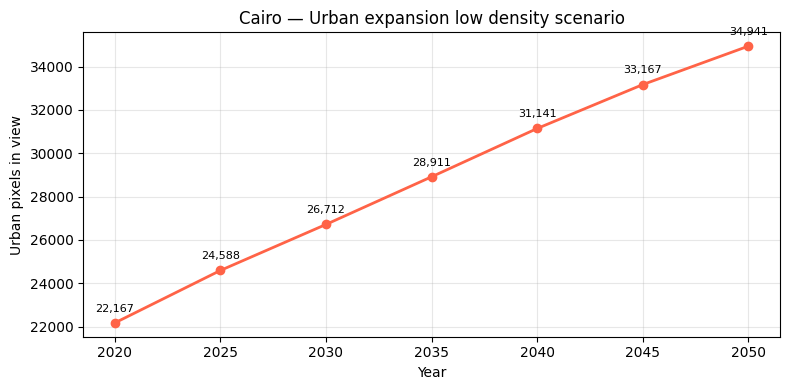

Urban pixel counts over time:
  2020: 22,167
  2025: 24,588
  2030: 26,712
  2035: 28,911
  2040: 31,141
  2045: 33,167
  2050: 34,941


In [12]:
# 看一个scenario随时间扩张的过程
SC_TIME = 'low'   # ← 选scenario
YEARS   = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

sc_kw_map = {'high':'highdensity', 'cons':'consdensity', 'low':'lowdensity'}
kw = sc_kw_map[SC_TIME]

all_tifs_sc = sorted(glob.glob(os.path.join(TIF_DIR, f'**/*{kw}*.tif'), recursive=True))
tifs_by_year = {}
for f in all_tifs_sc:
    m = re.search(r'(\d{4})\.tif$', f)
    if m:
        yr = int(m.group(1))
        if yr in YEARS:
            covering = [f for f in [f] if tif_covers(f, cx, cy)]
            if covering:
                tifs_by_year[yr] = covering[0]

print(f"Found time series: {sorted(tifs_by_year.keys())}")

urban_counts = {}
for yr, path in sorted(tifs_by_year.items()):
    with rasterio.open(path) as src:
        window = src.window(bbox['left'], bbox['bottom'], bbox['right'], bbox['top'])
        d = src.read(1, window=window).astype(float)
        nd = src.nodata
    if nd is not None: d[d==nd] = np.nan
    urban_counts[yr] = int(np.nansum(d > 0))

fig, ax = plt.subplots(figsize=(8, 4))
yrs = sorted(urban_counts.keys())
ax.plot(yrs, [urban_counts[y] for y in yrs], 'o-', color='tomato', linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('Urban pixels in view')
ax.set_title(f'{CITY_NAME} — Urban expansion {SC_TIME} density scenario')
ax.grid(True, alpha=0.3)
for yr in yrs:
    ax.annotate(f'{urban_counts[yr]:,}', (yr, urban_counts[yr]),
                textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("Urban pixel counts over time:")
for yr in yrs:
    print(f"  {yr}: {urban_counts[yr]:,}")

In [21]:
import pickle
import numpy as np

G_base = pickle.load(open("../output/Network_baseline.pkl", "rb"))
G_low  = pickle.load(open("../output/Network_urban_low_2050.pkl", "rb"))
G_cons = pickle.load(open("../output/Network_urban_cons_2050.pkl", "rb"))
G_high = pickle.load(open("../output/Network_urban_high_2050.pkl", "rb"))

vdf = G_base.get_vertex_dataframe()
name2idx = {r["agglosName"]: i for i, r in vdf.iterrows() if pd.notna(r.get("agglosName"))}

import pandas as pd
oi = name2idx.get("Lagos")
di = name2idx.get("Accra")
print(f"Lagos idx: {oi}, Accra idx: {di}")

path = G_base.get_shortest_paths(oi, di, weights=G_base.es["l"], output="epath")[0]
print(f"路径边数: {len(path)}")

print(f"\n{'eid':>6}  {'low_B50':>12}  {'cons_B50':>12}  {'high_B50':>12}  {'low_time':>10}  {'high_time':>10}")
for eid in path:
    bl = G_low.es[eid]["Between50"]
    bc = G_cons.es[eid]["Between50"]
    bh = G_high.es[eid]["Between50"]
    tl = G_low.es[eid]["timeU_lowd2050"]  if "timeU_lowd2050"  in G_low.es.attributes()  else "N/A"
    th = G_high.es[eid]["timeU_high2050"] if "timeU_high2050" in G_high.es.attributes() else "N/A"
    print(f"{eid:>6}  {bl:>12.1f}  {bc:>12.1f}  {bh:>12.1f}  {tl:>10.2f}  {th:>10.2f}")

Lagos idx: 317, Accra idx: 284
路径边数: 27

   eid       low_B50      cons_B50      high_B50    low_time   high_time
   785        1035.8        1035.9        1035.9        3.18        3.18
   776        1035.8        1035.9        1035.9       45.60       45.60
   777        1035.8        1035.9        1035.9        1.30        1.30
  8021        1035.8        1035.9        1035.9       32.52       26.70
  8022        1035.8        1035.9        1035.9       14.66       13.75
  8930        1035.8        1035.9        1035.9       12.73       12.73
  4267        1035.8        1035.9        1035.9       20.18       20.18
  4260        1035.8        1035.9        1035.9        2.21        2.21
  4261        1035.8        1035.9        1035.9        4.86        4.86
  4263        1035.8        1035.9        1035.9        2.55        2.55
  4264        1035.8        1035.9        1035.9        8.05        8.05
  7448           0.0           0.0           0.0        4.09        4.09
  7447    